In [2]:
%pip install matplotlib


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------- ------------------------------ 1.8/8.1 MB 11.2 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 15.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 14.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 14.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   -------------------- ------------------- 3.7/7.0 MB 24.2 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 21.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset shape: (10000, 18)

Return distribution:
Returned
1    0.5052
0    0.4948
Name: proportion, dtype: float64


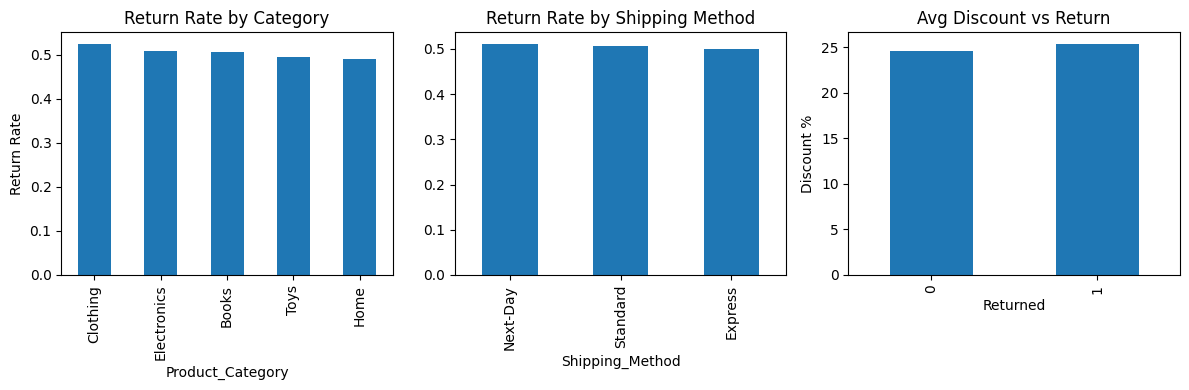

(Product_Category
 Clothing       0.524500
 Electronics    0.509320
 Books          0.506614
 Toys           0.495370
 Home           0.490148
 Name: Returned, dtype: float64,
 Shipping_Method
 Next-Day    0.510902
 Standard    0.505152
 Express     0.499395
 Name: Returned, dtype: float64,
 Returned
 0    24.624919
 1    25.351845
 Name: Discount_Applied, dtype: float64)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned data
df = pd.read_csv("../data/processed/cleaned_data.csv")

# Basic info
print("Dataset shape:", df.shape)
print("\nReturn distribution:")
print(df['Returned'].value_counts(normalize=True))

# Return rate by category
category_return = df.groupby('Product_Category')['Returned'].mean().sort_values(ascending=False)

# Return rate by shipping method
shipping_return = df.groupby('Shipping_Method')['Returned'].mean().sort_values(ascending=False)

# Discount vs return
discount_return = df.groupby('Returned')['Discount_Applied'].mean()

# Plots
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
category_return.plot(kind='bar', title='Return Rate by Category')
plt.ylabel('Return Rate')

plt.subplot(1,3,2)
shipping_return.plot(kind='bar', title='Return Rate by Shipping Method')

plt.subplot(1,3,3)
discount_return.plot(kind='bar', title='Avg Discount vs Return')
plt.ylabel('Discount %')

plt.tight_layout()
plt.show()

category_return, shipping_return, discount_return


## Final Business Recommendations

- Monitor and restrict excessive discounts to reduce return risk.
- Flag high-value orders for stricter return policies.
- Focus on customers with fast return behavior patterns.
- Use return-delay based rules to predict high-risk orders early.
